NumPy version: 2.4.6
TensorFlow version: 2.21.0
nu = 0.003183098861837907
x domain: -1.0 to 1.0
t domain: 0.0 to 1.0
X0 shape: (100, 2)
u0 shape: (100, 1)
X_left shape: (100, 2)
X_right shape: (100, 2)
X_u shape: (300, 2)
u_train shape: (300, 1)

First five supervised points:
x = -1.0 , t = 0.0 , u = 1.2246467991473532e-16
x = -0.9797979797979798 , t = 0.0 , u = 0.06342391965656484
x = -0.9595959595959596 , t = 0.0 , u = 0.12659245357374938
x = -0.9393939393939394 , t = 0.0 , u = 0.18925124436041008
x = -0.9191919191919192 , t = 0.0 , u = 0.2511479871810793
X_f shape: (10000, 2)

First five collocation points:
x = -0.250919762305275 , t = 0.3736408184666985
x = 0.9014286128198323 , t = 0.3329120962314033
x = 0.4639878836228102 , t = 0.17615391250286005
x = 0.1973169683940732 , t = 0.6072666701014879
x = -0.687962719115127 , t = 0.4766241605086289


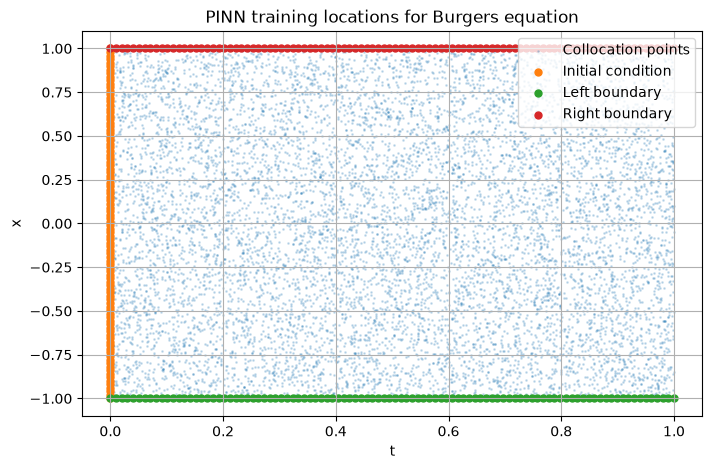

X_u dtype: float32
u_train dtype: float32
X_f dtype: float32
Lower bound: [-1.  0.]
Upper bound: [1. 1.]
Model test output shape: (5, 1)
Residual shape: (5, 1)
Initial total loss: 0.22156858
Initial supervised loss MSE_u: 0.16280411
Initial physics loss MSE_f: 0.058764465
Epoch     0 | Total Loss: 2.215686e-01 | MSE_u: 1.628041e-01 | MSE_f: 5.876447e-02
Epoch  1000 | Total Loss: 3.508542e-02 | MSE_u: 2.755439e-02 | MSE_f: 7.531023e-03
Epoch  2000 | Total Loss: 8.281880e-03 | MSE_u: 4.880898e-03 | MSE_f: 3.400982e-03
Epoch  3000 | Total Loss: 3.947169e-03 | MSE_u: 1.265393e-03 | MSE_f: 2.681776e-03
Epoch  4000 | Total Loss: 1.259657e-03 | MSE_u: 6.274477e-04 | MSE_f: 6.322093e-04
Epoch  5000 | Total Loss: 7.881561e-04 | MSE_u: 3.728638e-04 | MSE_f: 4.152924e-04
Epoch  6000 | Total Loss: 1.533837e-03 | MSE_u: 2.909714e-04 | MSE_f: 1.242865e-03
Epoch  7000 | Total Loss: 5.364687e-04 | MSE_u: 2.444802e-04 | MSE_f: 2.919885e-04
Epoch  8000 | Total Loss: 5.014621e-04 | MSE_u: 2.091615e-04 | 

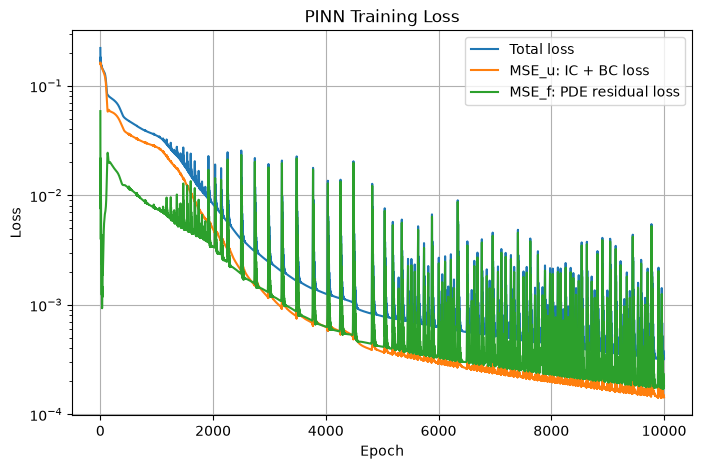

Prediction input shape: (25600, 2)
Predicted solution shape: (100, 256)


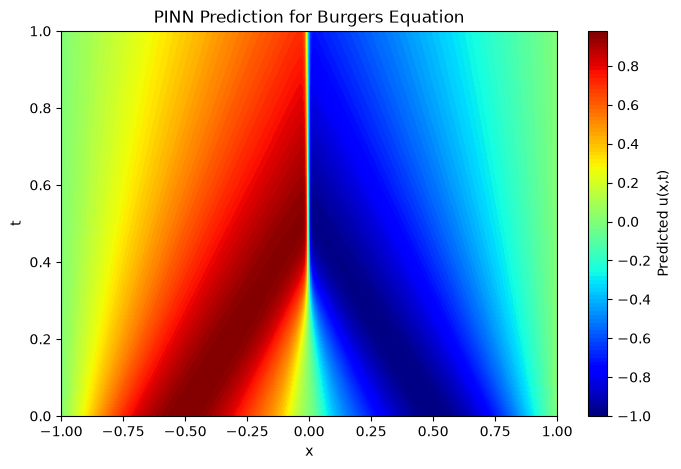

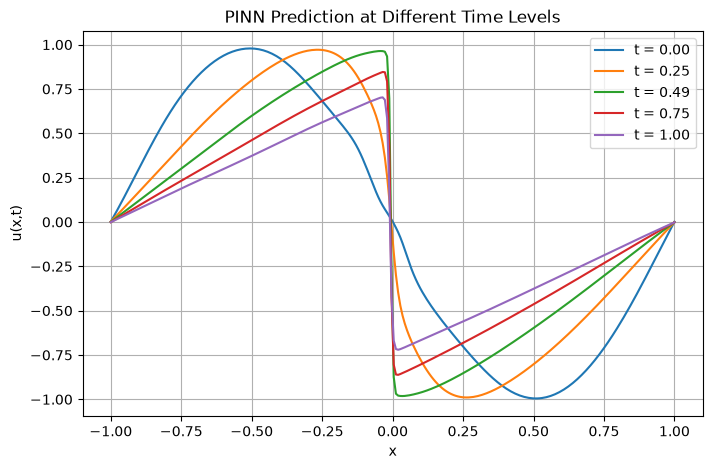

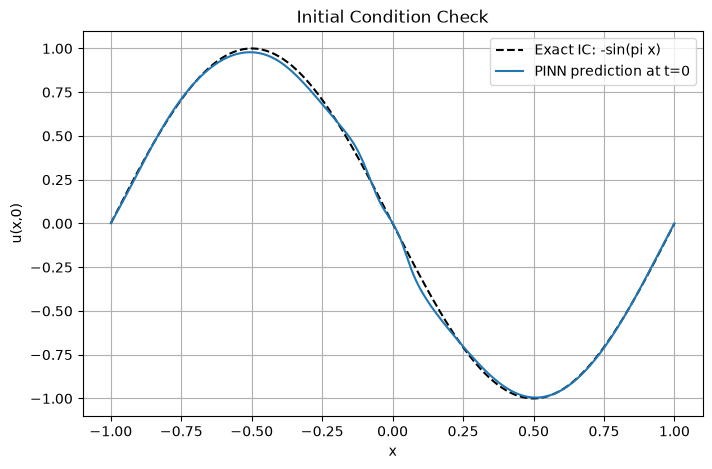

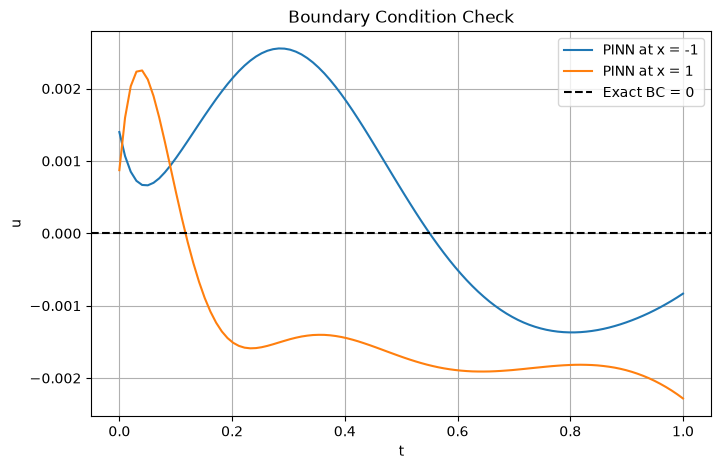

Final total loss: 0.00032759554
Final supervised loss MSE_u: 0.00014439988
Final physics loss MSE_f: 0.00018319566


In [1]:
# ============================================================
# Burgers Equation PINN — Corrected Full Code
# Convention used everywhere:
# X[:, 0] = x
# X[:, 1] = t
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

np.random.seed(42)
tf.random.set_seed(42)

print("NumPy version:", np.__version__)
print("TensorFlow version:", tf.__version__)


# ============================================================
# 1. Problem setup
# ============================================================

nu_value = 0.01 / np.pi
nu = tf.constant(nu_value, dtype=tf.float32)

x_min, x_max = -1.0, 1.0
t_min, t_max = 0.0, 1.0

print("nu =", nu_value)
print("x domain:", x_min, "to", x_max)
print("t domain:", t_min, "to", t_max)


# ============================================================
# 2. Initial-condition points
# u(x, 0) = -sin(pi x)
# ============================================================

N0 = 100

x0 = np.linspace(x_min, x_max, N0).reshape(-1, 1)
t0 = np.zeros_like(x0)

u0 = -np.sin(np.pi * x0)

# Important: input order is [x, t]
X0 = np.hstack([x0, t0])

print("X0 shape:", X0.shape)
print("u0 shape:", u0.shape)


# ============================================================
# 3. Boundary-condition points
# u(-1, t) = 0
# u( 1, t) = 0
# ============================================================

Nb = 100

tb = np.linspace(t_min, t_max, Nb).reshape(-1, 1)

x_left = x_min * np.ones_like(tb)
x_right = x_max * np.ones_like(tb)

u_left = np.zeros_like(tb)
u_right = np.zeros_like(tb)

# Important: input order is [x, t]
X_left = np.hstack([x_left, tb])
X_right = np.hstack([x_right, tb])

print("X_left shape:", X_left.shape)
print("X_right shape:", X_right.shape)


# ============================================================
# 4. Combine supervised points: IC + BC
# ============================================================

X_u = np.vstack([X0, X_left, X_right])
u_train = np.vstack([u0, u_left, u_right])

print("X_u shape:", X_u.shape)
print("u_train shape:", u_train.shape)

print("\nFirst five supervised points:")
for i in range(5):
    print("x =", X_u[i, 0], ", t =", X_u[i, 1], ", u =", u_train[i, 0])


# ============================================================
# 5. Collocation points
# PDE residual is enforced inside the full space-time domain
# ============================================================

Nf = 10000

x_f = x_min + (x_max - x_min) * np.random.rand(Nf, 1)
t_f = t_min + (t_max - t_min) * np.random.rand(Nf, 1)

# Important: input order is [x, t]
X_f = np.hstack([x_f, t_f])

print("X_f shape:", X_f.shape)

print("\nFirst five collocation points:")
for i in range(5):
    print("x =", X_f[i, 0], ", t =", X_f[i, 1])


# ============================================================
# 6. Plot training locations
# ============================================================

plt.figure(figsize=(8, 5))

# For visualization only, plot horizontal axis as t and vertical axis as x
plt.scatter(X_f[:, 1], X_f[:, 0], s=1, alpha=0.2, label="Collocation points")
plt.scatter(X0[:, 1], X0[:, 0], s=25, label="Initial condition")
plt.scatter(X_left[:, 1], X_left[:, 0], s=25, label="Left boundary")
plt.scatter(X_right[:, 1], X_right[:, 0], s=25, label="Right boundary")

plt.xlabel("t")
plt.ylabel("x")
plt.title("PINN training locations for Burgers equation")
plt.legend()
plt.grid(True)
plt.show()


# ============================================================
# 7. Convert to float32
# ============================================================

X_u = X_u.astype(np.float32)
u_train = u_train.astype(np.float32)
X_f = X_f.astype(np.float32)

X_u_tf = tf.convert_to_tensor(X_u, dtype=tf.float32)
u_train_tf = tf.convert_to_tensor(u_train, dtype=tf.float32)
X_f_tf = tf.convert_to_tensor(X_f, dtype=tf.float32)

print("X_u dtype:", X_u.dtype)
print("u_train dtype:", u_train.dtype)
print("X_f dtype:", X_f.dtype)


# ============================================================
# 8. Input normalization bounds
# ============================================================

X_all = np.vstack([X_u, X_f])

lb = tf.constant(X_all.min(axis=0), dtype=tf.float32)
ub = tf.constant(X_all.max(axis=0), dtype=tf.float32)

print("Lower bound:", lb.numpy())
print("Upper bound:", ub.numpy())

# Correct result should be approximately:
# Lower bound: [-1.  0.]
# Upper bound: [ 1.  1.]


# ============================================================
# 9. Define PINN model
# ============================================================

class PINN(tf.keras.Model):
    def __init__(self, layers, lb, ub):
        super(PINN, self).__init__()

        self.lb = lb
        self.ub = ub

        self.hidden_layers = []

        for width in layers[1:-1]:
            self.hidden_layers.append(
                tf.keras.layers.Dense(
                    width,
                    activation=tf.nn.tanh,
                    kernel_initializer="glorot_normal"
                )
            )

        self.output_layer = tf.keras.layers.Dense(
            layers[-1],
            activation=None,
            kernel_initializer="glorot_normal"
        )

    def call(self, X):
        # Normalize [x, t] to [-1, 1]
        H = 2.0 * (X - self.lb) / (self.ub - self.lb) - 1.0

        for layer in self.hidden_layers:
            H = layer(H)

        return self.output_layer(H)


layers = [2, 20, 20, 20, 20, 20, 1]
model = PINN(layers, lb, ub)

u_test = model(X_u_tf[:5])
print("Model test output shape:", u_test.shape)


# ============================================================
# 10. Burgers residual
# PDE:
# u_t + u u_x - nu u_xx = 0
# ============================================================

def burgers_residual(model, X_f):
    """
    Correct convention:

        X_f[:, 0] = x
        X_f[:, 1] = t

    Residual:

        f = u_t + u*u_x - nu*u_xx
    """

    with tf.GradientTape(persistent=True) as tape2:
        tape2.watch(X_f)

        with tf.GradientTape() as tape1:
            tape1.watch(X_f)

            u = model(X_f)

        grad_u = tape1.gradient(u, X_f)

        u_x = grad_u[:, 0:1]
        u_t = grad_u[:, 1:2]

    grad_u_x = tape2.gradient(u_x, X_f)
    u_xx = grad_u_x[:, 0:1]

    del tape2

    f = u_t + u * u_x - nu * u_xx

    return f


f_test = burgers_residual(model, X_f_tf[:5])
print("Residual shape:", f_test.shape)


# ============================================================
# 11. Loss function
# ============================================================

def loss_function(model, X_u, u_train, X_f):
    u_pred = model(X_u)
    f_pred = burgers_residual(model, X_f)

    mse_u = tf.reduce_mean(tf.square(u_train - u_pred))
    mse_f = tf.reduce_mean(tf.square(f_pred))

    total_loss = mse_u + mse_f

    return total_loss, mse_u, mse_f


total_loss, mse_u, mse_f = loss_function(model, X_u_tf, u_train_tf, X_f_tf)

print("Initial total loss:", total_loss.numpy())
print("Initial supervised loss MSE_u:", mse_u.numpy())
print("Initial physics loss MSE_f:", mse_f.numpy())


# ============================================================
# 12. Training
# ============================================================

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)

@tf.function
def train_step():
    with tf.GradientTape() as tape:
        total_loss, mse_u, mse_f = loss_function(
            model,
            X_u_tf,
            u_train_tf,
            X_f_tf
        )

    gradients = tape.gradient(total_loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))

    return total_loss, mse_u, mse_f


epochs = 10000

loss_history = []
mse_u_history = []
mse_f_history = []

for epoch in range(epochs):
    total_loss, mse_u, mse_f = train_step()

    loss_history.append(total_loss.numpy())
    mse_u_history.append(mse_u.numpy())
    mse_f_history.append(mse_f.numpy())

    if epoch % 1000 == 0:
        print(
            f"Epoch {epoch:5d} | "
            f"Total Loss: {total_loss.numpy():.6e} | "
            f"MSE_u: {mse_u.numpy():.6e} | "
            f"MSE_f: {mse_f.numpy():.6e}"
        )


# ============================================================
# 13. Plot loss history
# ============================================================

plt.figure(figsize=(8, 5))

plt.semilogy(loss_history, label="Total loss")
plt.semilogy(mse_u_history, label="MSE_u: IC + BC loss")
plt.semilogy(mse_f_history, label="MSE_f: PDE residual loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("PINN Training Loss")
plt.legend()
plt.grid(True)
plt.show()


# ============================================================
# 14. Prediction grid
# ============================================================

Nx_plot = 256
Nt_plot = 100

x_plot = np.linspace(x_min, x_max, Nx_plot)
t_plot = np.linspace(t_min, t_max, Nt_plot)

X_grid, T_grid = np.meshgrid(x_plot, t_plot)

# Correct convention: [x, t]
X_pred = np.hstack([
    X_grid.flatten()[:, None],
    T_grid.flatten()[:, None]
])

X_pred = X_pred.astype(np.float32)
X_pred_tf = tf.convert_to_tensor(X_pred, dtype=tf.float32)

u_pred = model(X_pred_tf).numpy()

U_pred = u_pred.reshape(Nt_plot, Nx_plot)

print("Prediction input shape:", X_pred.shape)
print("Predicted solution shape:", U_pred.shape)


# ============================================================
# 15. Contour plot
# ============================================================

plt.figure(figsize=(8, 5))

plt.contourf(X_grid, T_grid, U_pred, levels=100, cmap="jet")
plt.colorbar(label="Predicted u(x,t)")

plt.xlabel("x")
plt.ylabel("t")
plt.title("PINN Prediction for Burgers Equation")

plt.show()


# ============================================================
# 16. Line plots at selected time levels
# ============================================================

time_levels = [0.0, 0.25, 0.50, 0.75, 1.0]

plt.figure(figsize=(8, 5))

for t_val in time_levels:
    idx = np.argmin(np.abs(t_plot - t_val))

    plt.plot(
        x_plot,
        U_pred[idx, :],
        label=f"t = {t_plot[idx]:.2f}"
    )

plt.xlabel("x")
plt.ylabel("u(x,t)")
plt.title("PINN Prediction at Different Time Levels")
plt.legend()
plt.grid(True)
plt.show()


# ============================================================
# 17. Initial-condition check
# ============================================================

u_initial_exact = -np.sin(np.pi * x_plot)

idx_t0 = np.argmin(np.abs(t_plot - 0.0))
u_initial_pred = U_pred[idx_t0, :]

plt.figure(figsize=(8, 5))

plt.plot(x_plot, u_initial_exact, "k--", label="Exact IC: -sin(pi x)")
plt.plot(x_plot, u_initial_pred, label="PINN prediction at t=0")

plt.xlabel("x")
plt.ylabel("u(x,0)")
plt.title("Initial Condition Check")
plt.legend()
plt.grid(True)
plt.show()


# ============================================================
# 18. Boundary-condition check
# ============================================================

u_left_boundary = U_pred[:, 0]
u_right_boundary = U_pred[:, -1]

plt.figure(figsize=(8, 5))

plt.plot(t_plot, u_left_boundary, label="PINN at x = -1")
plt.plot(t_plot, u_right_boundary, label="PINN at x = 1")

plt.axhline(0.0, color="k", linestyle="--", label="Exact BC = 0")

plt.xlabel("t")
plt.ylabel("u")
plt.title("Boundary Condition Check")
plt.legend()
plt.grid(True)
plt.show()


# ============================================================
# 19. Final loss check
# ============================================================

total_loss, mse_u, mse_f = loss_function(model, X_u_tf, u_train_tf, X_f_tf)

print("Final total loss:", total_loss.numpy())
print("Final supervised loss MSE_u:", mse_u.numpy())
print("Final physics loss MSE_f:", mse_f.numpy())